# Preliminary Modelling and Results

The current implementation is intended as a preliminary prototype to help me develop an understanding of operating envelope calculation and the underlying optimal power flow framework.


# 1. Network Data

The synthetic 13-node feeder data, including load, voltage limits, line parameters, thermal limits, and topology, were adapted from the GitHub OPF example.

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

#Node Data
l_P = np.array([0, 0.2, 0, 0.4, 0.17, 0.23, 1.155,
                0, 0.17, 0.843, 0, 0.17, 0.128])

l_Q = np.array([0, 0.116, 0, 0.29, 0.125, 0.132,
                0.66, 0, 0.151, 0.462, 0, 0.08, 0.086])

s_max = np.array([5, 0, 0, 3, 0, 0, 0, 0, 0, 3, 0, 0, 0])

v_min = 0.95
v_max = 1.05

# Line Data
r = np.array([
[0, 0.007547918, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0041, 0, 0.007239685, 0, 0.007547918, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004343811, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.003773959, 0, 0, 0.004322245, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00434686, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004343157, 0.01169764],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

x = np.array([
[0, 0.022173236, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0064, 0, 0.007336076, 0, 0.022173236, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004401645, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.011086618, 0, 0, 0.004433667, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.002430473, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004402952, 0.004490848],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

I_max = np.array([
[0, 3.0441, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1.4178, 0, 0.9591, 0, 3.0441, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 3.1275, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.9591, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 3.0441, 3.1275, 0, 0.9591, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1.37193, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9591, 1.2927],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

A = np.array([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])


# 2. Core OPF Functions

The following functions implement the linearized DistFlow OPF model used to compute operating envelopes.
For export OE, the optimisation variable represents additional export above the forecast export level.
For import OE, the optimisation variable represents additional import above the forecast operating condition.

I also add a simple binding-constraint diagnostics after solving the OPF.

In [2]:
def _build_opf(
    l_P_t,             # active load demand (MW)
    l_Q_t,             # reactive load demand (MVAr)
    p_forecast_t,      # forecast DER export (MW)
    q_forecast_t,      # forecast DER reactive support (MVAr)
    target_node,       # customer/node being analysed
    mode,              # "export" or "import"
    limit=10.0         # upper bound for optimisation variable
):
    n = len(l_P_t)

    edges = [
        (i, j)
        for i in range(n)
        for j in range(n)
        if A[i, j] == 1
    ]

    P = cp.Variable((n, n))   # Active power flow
    Q = cp.Variable((n, n))   # Reactive power flow
    v = cp.Variable(n)        # Squared voltage magnitude

    target = cp.Variable()    # Additional export/import capability

    constraints = [
        v[0] == 1.0,          # Slack bus voltage fixed at 1.0 p.u.
        v >= v_min ** 2,      # Voltage limits
        v <= v_max ** 2,
        target >= 0,          # Target variable bounds
        target <= limit
    ]
    # Remove flows on non-existing lines
    for i in range(n):
        for j in range(n):
            if A[i, j] == 0:
                constraints += [
                    P[i, j] == 0,
                    Q[i, j] == 0
                ]
    # DistFlow equations
    for (i, j) in edges:
        children = [
            k
            for k in range(n)
            if A[j, k] == 1
        ]
        # Net active power injection
        if j == target_node:
            # increase DER export at target node
            if mode == "export":
                p_net_j = l_P_t[j] - p_forecast_t[j] - target
            # increase customer demand at target node
            elif mode == "import":
                p_net_j = l_P_t[j] - p_forecast_t[j] + target

            else:
                raise ValueError("mode must be 'export' or 'import'")

        else:
            p_net_j = l_P_t[j] - p_forecast_t[j]

        q_net_j = l_Q_t[j] - q_forecast_t[j]
        # DistFlow power balance equations
        constraints += [
            P[i, j] == p_net_j + cp.sum([
                P[j, k]
                for k in children
            ]),

            Q[i, j] == q_net_j + cp.sum([
                Q[j, k]
                for k in children
            ]),
            # Linearized DistFlow voltage equation
            v[j] == v[i] - 2 * (
                r[i, j] * P[i, j]
                + x[i, j] * Q[i, j]
            ),
            # Thermal line loading limit
            cp.norm(
                cp.hstack([P[i, j], Q[i, j]]),
                2
            ) <= I_max[i, j]
        ]

    problem = cp.Problem(
        cp.Maximize(target),
        constraints
    )

    problem.solve()

    voltage = (
        np.sqrt(np.maximum(v.value, 0))
        if v.value is not None
        else None
    )

    binding_voltage_upper = False
    binding_voltage_lower = False
    binding_thermal = False

    if voltage is not None:

        if np.any(np.abs(voltage - v_max) < 1e-3):
            binding_voltage_upper = True

        if np.any(np.abs(voltage - v_min) < 1e-3):
            binding_voltage_lower = True

    if P.value is not None:

        for (i, j) in edges:

            apparent_flow = np.sqrt(
                P.value[i, j] ** 2
                + Q.value[i, j] ** 2
            )

            if abs(apparent_flow - I_max[i, j]) < 1e-3:
                binding_thermal = True
                break

    return {
        "status": problem.status,
        "value": target.value,
        "voltage": voltage,
        "P_flow": P.value,
        "Q_flow": Q.value,
        "binding_voltage_upper": binding_voltage_upper,
        "binding_voltage_lower": binding_voltage_lower,
        "binding_thermal": binding_thermal
    }


def solve_max_outflow(
    target_node,
    l_P_t,
    l_Q_t,
    p_forecast_t,
    q_forecast_t
):
    return _build_opf(
        l_P_t,
        l_Q_t,
        p_forecast_t,
        q_forecast_t,
        target_node,
        mode="export"
    )


def solve_max_import(
    target_node,
    l_P_t,
    l_Q_t,
    p_forecast_t,
    q_forecast_t
):
    return _build_opf(
        l_P_t,
        l_Q_t,
        p_forecast_t,
        q_forecast_t,
        target_node,
        mode="import"
    )


def print_oe_summary(
    result,
    l_P_t,
    l_Q_t,
    p_forecast_t,
    q_forecast_t,
    target_node,
    mode="export"
):
    status = result["status"]
    value = result["value"]
    voltage = result["voltage"]

    if mode == "export":
        total_oe = (
            p_forecast_t[target_node] + value
            if value is not None
            else None
        )

        print("Status              :", status)
        print("Node                :", target_node)
        print("Forecast export     :", p_forecast_t[target_node])
        print("Additional export   :", value)
        print("Export OE limit     :", total_oe)

    else:
        print("Status              :", status)
        print("Node                :", target_node)
        print("Import OE limit     :", value)

    print()

    total_load_P = np.sum(l_P_t)
    total_load_Q = np.sum(l_Q_t)
    total_load_S = np.sqrt(total_load_P ** 2 + total_load_Q ** 2)

    total_gen_P = np.sum(p_forecast_t)
    total_gen_Q = np.sum(q_forecast_t)

    if mode == "export" and value is not None:
        total_gen_P += value

    total_gen_S = np.sqrt(total_gen_P ** 2 + total_gen_Q ** 2)

    print(
        f"Total active power   : {total_load_P:.3f} MW   consumed"
        f" | {total_gen_P:.3f} MW   generated"
    )

    print(
        f"Total reactive power : {total_load_Q:.3f} MVAr consumed"
        f" | {total_gen_Q:.3f} MVAr generated"
    )

    print(
        f"Total apparent power : {total_load_S:.3f} MVA  consumed"
        f" | {total_gen_S:.3f} MVA  generated"
    )

    print()

    if voltage is not None:
        for j, v_j in enumerate(voltage):
            print(f"  Node {j:2d} voltage : {v_j:.3f} p.u.")

    print()

# 3. Static Operating Envelope Assessment

Node 9 is selected to test the operating envelope calculation framework under a single operating condition.

Node 9 is assumed to have a forecasted DER export of 1.941 MW and reactive support of 1.216 MVAr.（The assumed data is from Github example.)

The export OE is reported as:

Export OE = Forecast Export + Additional Export Capacity

In [3]:
p_forecast_base = np.zeros(len(l_P))
q_forecast_base = np.zeros(len(l_Q))

p_forecast_base[9] = 1.941
q_forecast_base[9] = 1.216


print("=" * 50)
print("Export OE — Node 9")
print("=" * 50)

res9_exp = solve_max_outflow(
    9,
    l_P,
    l_Q,
    p_forecast_base,
    q_forecast_base
)

print("\nBinding Constraint Analysis")
print("---------------------------")

print(
    "Voltage upper binding :",
    res9_exp["binding_voltage_upper"]
)

print(
    "Voltage lower binding :",
    res9_exp["binding_voltage_lower"]
)

print(
    "Thermal binding :",
    res9_exp["binding_thermal"]
)

print_oe_summary(
    res9_exp,
    l_P,
    l_Q,
    p_forecast_base,
    q_forecast_base,
    target_node=9,
    mode="export"
)


print("=" * 50)
print("Import OE — Node 9")
print("=" * 50)

res9_imp = solve_max_import(
    9,
    l_P,
    l_Q,
    p_forecast_base,
    q_forecast_base
)

print_oe_summary(
    res9_imp,
    l_P,
    l_Q,
    p_forecast_base,
    q_forecast_base,
    target_node=9,
    mode="import"
)

Export OE — Node 9

Binding Constraint Analysis
---------------------------
Voltage upper binding : False
Voltage lower binding : False
Thermal binding : True
Status              : optimal
Node                : 9
Forecast export     : 1.941
Additional export   : 0.0481570255598837
Export OE limit     : 1.9891570255598838

Total active power   : 3.466 MW   consumed | 1.989 MW   generated
Total reactive power : 2.102 MVAr consumed | 1.216 MVAr generated
Total apparent power : 4.054 MVA  consumed | 2.331 MVA  generated

  Node  0 voltage : 1.000 p.u.
  Node  1 voltage : 0.969 p.u.
  Node  2 voltage : 0.965 p.u.
  Node  3 voltage : 0.965 p.u.
  Node  4 voltage : 0.964 p.u.
  Node  5 voltage : 0.962 p.u.
  Node  6 voltage : 0.960 p.u.
  Node  7 voltage : 0.960 p.u.
  Node  8 voltage : 0.960 p.u.
  Node  9 voltage : 0.967 p.u.
  Node 10 voltage : 0.958 p.u.
  Node 11 voltage : 0.957 p.u.
  Node 12 voltage : 0.956 p.u.

Import OE — Node 9
Status              : optimal
Node                : 9


The OPF returns optimal solutions, all voltage magnitudes remain within the prescribed limits, and the calculated operating envelopes are bounded by active network constraints. This suggests that the implementation is behaving consistently with the intended OE formulation.

# 4. Node-by-Node Operating Envelopes



In [4]:
export_static = []

for node in range(1, len(l_P)):

    res = solve_max_outflow(
        node,
        l_P,
        l_Q,
        p_forecast_base,
        q_forecast_base
    )

    additional = res["value"]

    if additional is None:
        export_oe = None
    else:
        export_oe = p_forecast_base[node] + additional

    export_static.append({
        "node": node,
        "status": res["status"],
        "forecast_export": p_forecast_base[node],
        "additional_export": additional,
        "export_OE": export_oe
    })

df_export_static = pd.DataFrame(export_static)

print("Export OE for All Nodes")
print("-----------------------")
print(df_export_static)


import_static = []

for node in range(1, len(l_P)):

    res = solve_max_import(
        node,
        l_P,
        l_Q,
        p_forecast_base,
        q_forecast_base
    )

    import_static.append({
        "node": node,
        "status": res["status"],
        "import_OE": res["value"]
    })

df_import_static = pd.DataFrame(import_static)

print("\nImport OE for All Nodes")
print("-----------------------")
print(df_import_static)

Export OE for All Nodes
-----------------------
    node   status  forecast_export   additional_export  export_OE
0      1  optimal            0.000  4.4373098755826215   4.437310
1      2  optimal            0.000  1.7878244990254495   1.787824
2      3  optimal            0.000   1.787824499011016   1.787824
3      4  optimal            0.000   1.324025870916014   1.324026
4      5  optimal            0.000  1.1799730575282938   1.179973
5      6  optimal            0.000  3.5609209163991697   3.560921
6      7  optimal            0.000  3.0441000000479326   3.044100
7      8  optimal            0.000  2.1408185450387416   2.140819
8      9  optimal            1.941  0.0481570255598837   1.989157
9     10  optimal            0.000  1.2426252220081322   1.242625
10    11  optimal            0.000  1.1257577151384945   1.125758
11    12  optimal            0.000  1.2426252220080876   1.242625

Import OE for All Nodes
-----------------------
    node   status            import_OE
0     

In [5]:
def plot_network(oe_dict, title, cbar_label):
    G = nx.DiGraph()

    for i in range(len(A)):
        for j in range(len(A)):
            if A[i, j] == 1:
                G.add_edge(i, j)

    pos = {
        0: (0, 0),
        1: (0, -1),
        2: (-2, -2),
        3: (-2, -3),
        4: (0, -2),
        5: (0, -3),
        6: (2, -2),
        7: (1, -3),
        8: (2, -3),
        9: (2, -4),
        10: (3, -3),
        11: (2.5, -4),
        12: (3.5, -4)
    }

    colors = [
        0 if nd == 0 else (oe_dict.get(nd) or 0)
        for nd in G.nodes()
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    nd_draw = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        cmap=plt.cm.viridis,
        node_size=2000,
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        ax=ax
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        ax=ax
    )

    fig.colorbar(nd_draw, ax=ax).set_label(cbar_label)

    ax.set_title(title)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

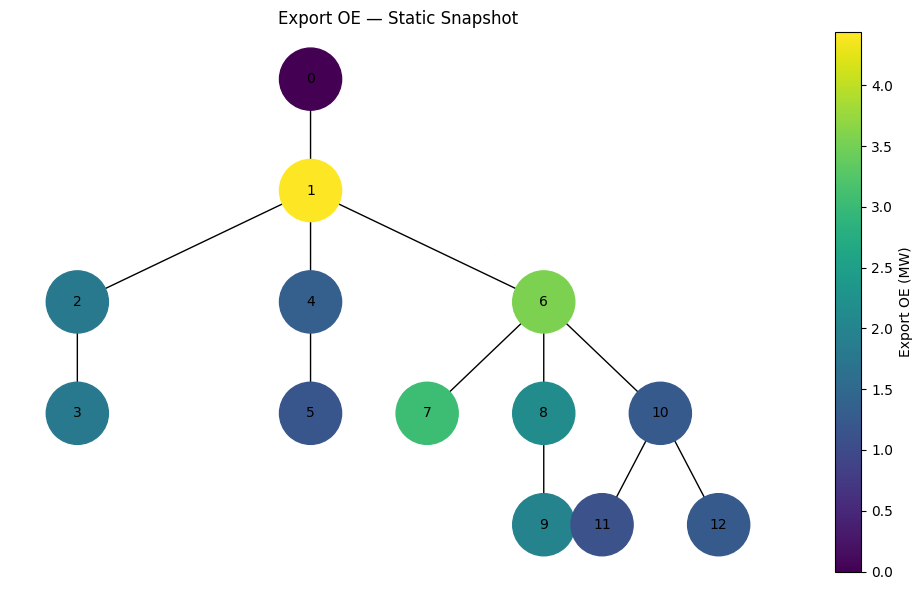

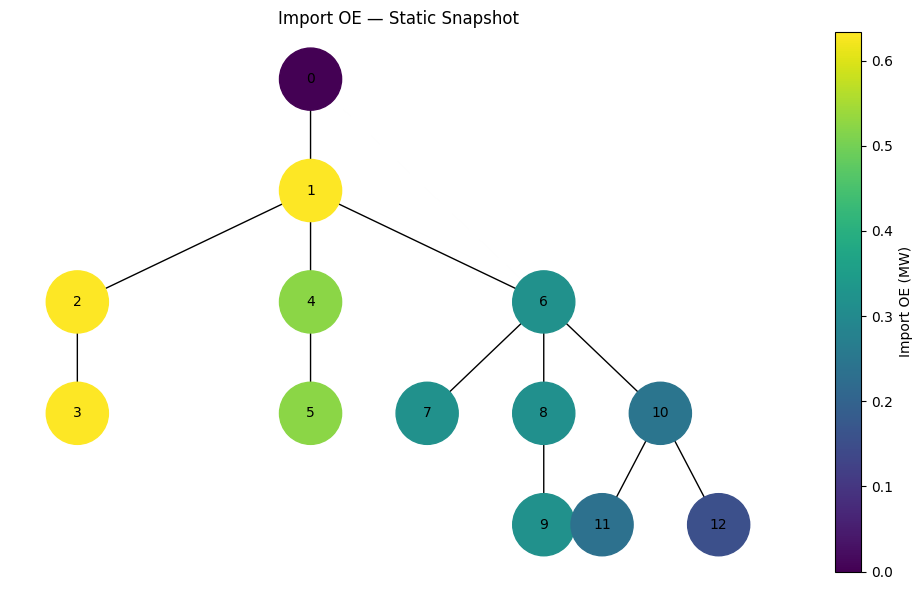

In [6]:
plot_network(
    {
        row["node"]: row["export_OE"]
        for row in export_static
    },
    "Export OE — Static Snapshot",
    "Export OE (MW)"
)

plot_network(
    {
        row["node"]: row["import_OE"]
        for row in import_static
    },
    "Import OE — Static Snapshot",
    "Import OE (MW)"
)

The static node-by-node results show substantial variation in operating envelopes across customer locations.
This suggests that customer location and feeder topology can strongly influence the export and import capability available to each customer.

# 5. Time-Varying Operating Envelopes

I further incorporated this time-varying characteristic of OE and I use the synthetic data to test the modelling framework.

In [7]:
base_l_P = l_P.copy()
base_l_Q = l_Q.copy()

hours = np.arange(24)

load_multiplier = np.array([
    0.50, 0.48, 0.46, 0.46, 0.48, 0.50,
    0.52, 0.55, 0.58, 0.60, 0.60, 0.58,
    0.56, 0.55, 0.56, 0.58, 0.60, 0.62,
    0.65, 0.62, 0.58, 0.55, 0.52, 0.50
])

pv_multiplier = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    0.03, 0.08, 0.15, 0.25, 0.35, 0.45,
    0.50, 0.45, 0.35, 0.25, 0.15, 0.08,
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00
])

pv_capacity = np.zeros(len(base_l_P))
pv_capacity[9] = 1.941

q_der_capacity = np.zeros(len(base_l_Q))
q_der_capacity[9] = 1.216

In [8]:
print("\nRunning time-varying OE...")

tv_results = []

for t in hours:
    # Hourly active and reactive demand
    l_P_t = base_l_P * load_multiplier[t]
    l_Q_t = base_l_Q * load_multiplier[t]
    # Hourly DER active and reactive forecasts
    p_forecast_t = pv_capacity * pv_multiplier[t]
    q_forecast_t = q_der_capacity * pv_multiplier[t]

    for node in range(1, len(base_l_P)):

        exp = solve_max_outflow(
            node,
            l_P_t,
            l_Q_t,
            p_forecast_t,
            q_forecast_t
        )

        additional_export = exp["value"]

        if additional_export is None:
            export_oe = np.nan
        else:
            export_oe = p_forecast_t[node] + additional_export

        imp = solve_max_import(
            node,
            l_P_t,
            l_Q_t,
            p_forecast_t,
            q_forecast_t
        )

        import_oe = imp["value"]

        if import_oe is None:
            import_oe_for_plot = 0.0
        else:
            import_oe_for_plot = import_oe

        tv_results.append({
            "hour": t,
            "node": node,
            "load_multiplier": load_multiplier[t],
            "pv_multiplier": pv_multiplier[t],
            "forecast_export": p_forecast_t[node],
            "export_status": exp["status"],
            "additional_export": additional_export,
            "export_OE": export_oe,
            "voltage_upper_binding": exp["binding_voltage_upper"],
            "voltage_lower_binding": exp["binding_voltage_lower"],
            "thermal_binding": exp["binding_thermal"],
            "import_status": imp["status"],
            "import_OE_raw": import_oe,
            "import_OE": import_oe_for_plot
        })

df_tv = pd.DataFrame(tv_results)

print(df_tv)


Running time-varying OE...
     hour  node  load_multiplier  pv_multiplier  forecast_export  \
0       0     1              0.5            0.0              0.0   
1       0     2              0.5            0.0              0.0   
2       0     3              0.5            0.0              0.0   
3       0     4              0.5            0.0              0.0   
4       0     5              0.5            0.0              0.0   
..    ...   ...              ...            ...              ...   
283    23     8              0.5            0.0              0.0   
284    23     9              0.5            0.0              0.0   
285    23    10              0.5            0.0              0.0   
286    23    11              0.5            0.0              0.0   
287    23    12              0.5            0.0              0.0   

    export_status   additional_export  export_OE  voltage_upper_binding  \
0         optimal   4.589911586427885   4.589912                  False   
1    


Node 9 time-varying OE
----------------------
 hour  forecast_export  additional_export  export_OE import_status       import_OE_raw           import_OE  load_multiplier  pv_multiplier
    0          0.00000 1.7738427554161242   1.773843    infeasible                None                 0.0             0.50           0.00
    1          0.00000  1.758528632843117   1.758529    infeasible                None                 0.0             0.48           0.00
    2          0.00000  1.743149756647273   1.743150    infeasible                None                 0.0             0.46           0.00
    3          0.00000  1.743149756647273   1.743150    infeasible                None                 0.0             0.46           0.00
    4          0.00000  1.758528632843117   1.758529    infeasible                None                 0.0             0.48           0.00
    5          0.00000 1.7738427554161242   1.773843    infeasible                None                 0.0             

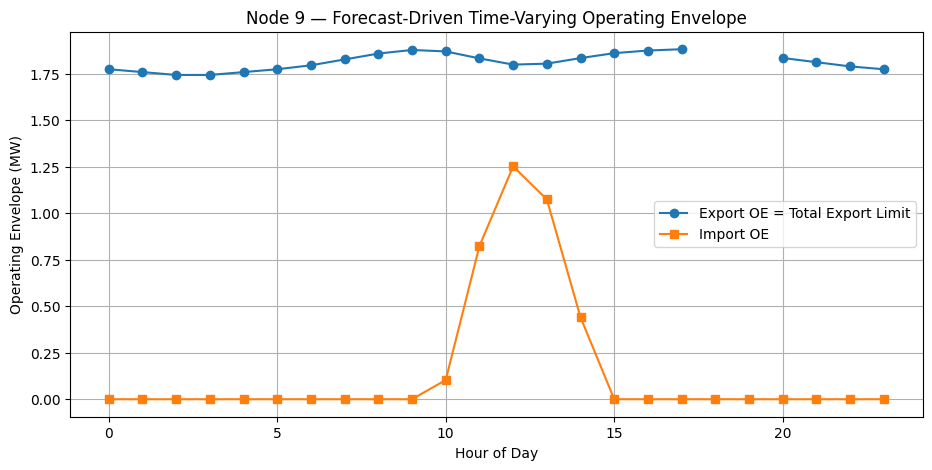

In [9]:
n9 = df_tv[df_tv["node"] == 9].copy()

n9["export_OE"] = pd.to_numeric(
    n9["export_OE"],
    errors="coerce"
)

n9["import_OE"] = pd.to_numeric(
    n9["import_OE"],
    errors="coerce"
)

print("\nNode 9 time-varying OE")
print("----------------------")
print(
    n9[
        [
            "hour",
            "forecast_export",
            "additional_export",
            "export_OE",
            "import_status",
            "import_OE_raw",
            "import_OE",
            "load_multiplier",
            "pv_multiplier"
        ]
    ].to_string(index=False)
)

plt.figure(figsize=(11, 5))

plt.plot(
    n9["hour"],
    n9["export_OE"],
    marker="o",
    label="Export OE = Total Export Limit"
)

plt.plot(
    n9["hour"],
    n9["import_OE"],
    marker="s",
    label="Import OE"
)

plt.xlabel("Hour of Day")
plt.ylabel("Operating Envelope (MW)")
plt.title("Node 9 — Forecast-Driven Time-Varying Operating Envelope")

plt.grid(True)
plt.legend()
plt.show()

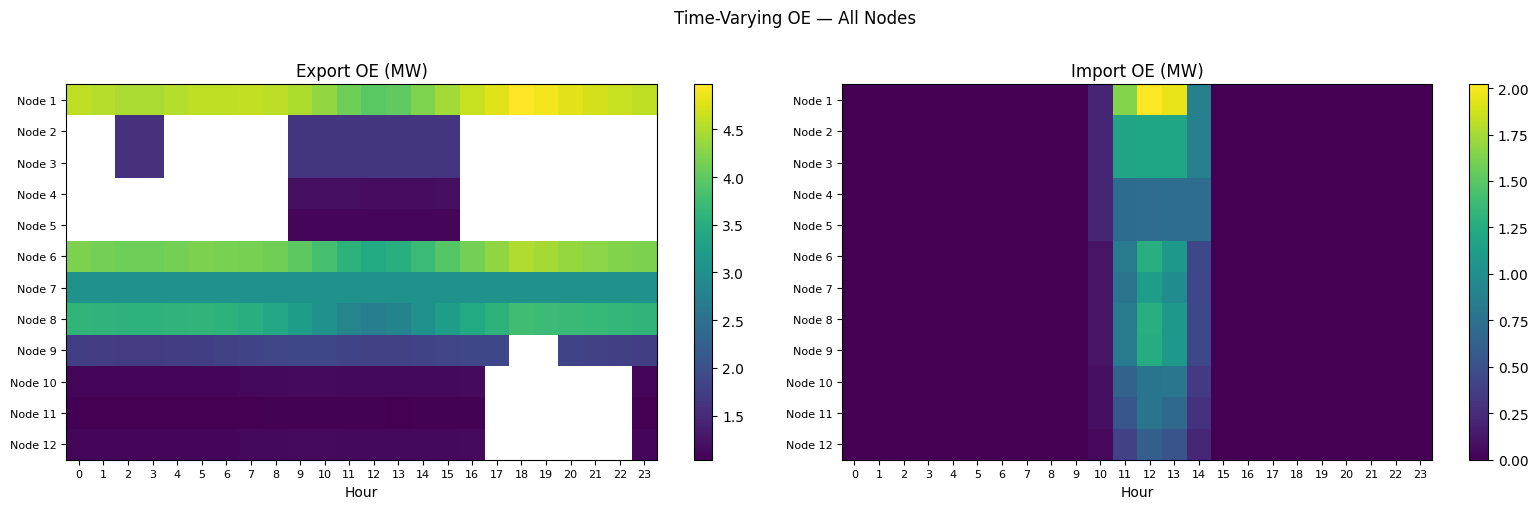

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["export_OE", "import_OE"],
    ["Export OE (MW)", "Import OE (MW)"]
):
    pivot = df_tv.pivot(
        index="node",
        columns="hour",
        values=col
    )

    im = ax.imshow(
        pivot.values.astype(float),
        aspect="auto",
        cmap="viridis",
        origin="upper"
    )

    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=8)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(
        [f"Node {nd}" for nd in pivot.index],
        fontsize=8
    )

    ax.set_xlabel("Hour")
    ax.set_title(title)

    fig.colorbar(im, ax=ax)

plt.suptitle("Time-Varying OE — All Nodes", y=1.01)
plt.tight_layout()
plt.show()

For Node 9, the export OE varies between approximately 1.74 MW and 1.89 MW throughout the day. The variation is relatively small despite changes in load and PV generation. Constraint binding analysis indicates that thermal limits are active in most feasible export OE calculations, suggesting that feeder thermal capacity is the dominant limiting factor in the current prototype network.

One observation that requires further investigation is that the export OE problem becomes infeasible during several hours (hours 18–19), even though an export OE of zero would be expected to remain feasible. This may indicate that the underlying operating point itself becomes infeasible under the assumed synthetic load and PV conditions, or that there are modelling assumptions that require further review.

The import OE exhibits a different behaviour. Feasible import envelopes are obtained only during a limited number of hours around midday, while the optimisation is infeasible during most other periods. A possible explanation is that the availability of PV generation and reactive power support improves feeder voltages during these hours, allowing additional import capacity. However, it is not yet clear whether the observed infeasibilities represent genuine network limitations or artefacts of the simplified assumptions used in the current prototype.

# 6. Constraint Binding Analysis



In [11]:
print("\nConstraint Binding Summary")
print("--------------------------")

df_tv_optimal = df_tv[df_tv["export_status"] == "optimal"].copy()

print(
    "Number of feasible export OE cases:",
    len(df_tv_optimal)
)

print(
    "Voltage upper bound active:",
    df_tv_optimal["voltage_upper_binding"].sum(),
    "times"
)

print(
    "Voltage lower bound active:",
    df_tv_optimal["voltage_lower_binding"].sum(),
    "times"
)

print(
    "Thermal limit active:",
    df_tv_optimal["thermal_binding"].sum(),
    "times"
)


Constraint Binding Summary
--------------------------
Number of feasible export OE cases: 204
Voltage upper bound active: 0 times
Voltage lower bound active: 4 times
Thermal limit active: 204 times


Thermal limits are active in most feasible export OE calculations. In the current prototype, line loading is the dominant factor restricting export flexibility.

# 7. Customer Disparity Analysis


In [18]:
print("\nCustomer Disparity Analysis")
print("---------------------------")

export_values = pd.to_numeric(
    df_export_static["export_OE"],
    errors="coerce"
).dropna()

import_values = pd.to_numeric(
    df_import_static["import_OE"],
    errors="coerce"
).dropna()

disparity_summary = pd.DataFrame([
    {
        "OE_type": "Export OE",
        "min_OE": export_values.min(),
        "max_OE": export_values.max(),
        "mean_OE": export_values.mean(),
        "std_OE": export_values.std(),
        "range_OE": export_values.max() - export_values.min(),
        "max_min_ratio": export_values.max() / export_values.min()
    },
    {
        "OE_type": "Import OE",
        "min_OE": import_values.min(),
        "max_OE": import_values.max(),
        "mean_OE": import_values.mean(),
        "std_OE": import_values.std(),
        "range_OE": import_values.max() - import_values.min(),
        "max_min_ratio": import_values.max() / import_values.min()
    }
])

print(disparity_summary)

print("\nSummary")
print("-------")

print(
    f"Export OE range : "
    f"{export_values.min():.3f} - "
    f"{export_values.max():.3f} MW"
)

print(
    f"Import OE range : "
    f"{import_values.min():.3f} - "
    f"{import_values.max():.3f} MW"
)

print(
    f"Export disparity ratio : "
    f"{export_values.max()/export_values.min():.2f}x"
)

print(
    f"Import disparity ratio : "
    f"{import_values.max()/import_values.min():.2f}x"
)


Customer Disparity Analysis
---------------------------
     OE_type               min_OE              max_OE   mean_OE    std_OE  \
0  Export OE             1.125758             4.43731  2.071914  1.068386   
1  Import OE  0.15359183904164514  0.6331707443062701  0.404010  0.174068   

   range_OE  max_min_ratio  
0  3.311552       3.941621  
1  0.479579       4.122424  

Summary
-------
Export OE range : 1.126 - 4.437 MW
Import OE range : 0.154 - 0.633 MW
Export disparity ratio : 3.94x
Import disparity ratio : 4.12x


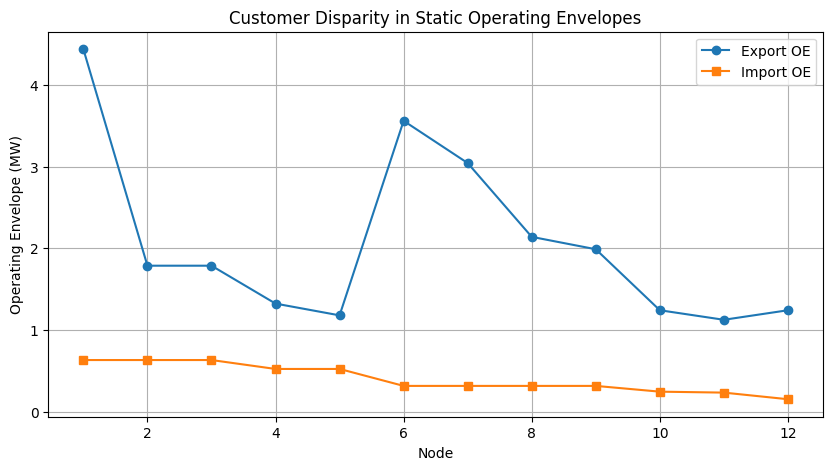

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_export_static["node"],
    df_export_static["export_OE"],
    marker="o",
    label="Export OE"
)

plt.plot(
    df_import_static["node"],
    df_import_static["import_OE"],
    marker="s",
    label="Import OE"
)

plt.xlabel("Node")
plt.ylabel("Operating Envelope (MW)")
plt.title("Customer Disparity in Static Operating Envelopes")

plt.grid(True)
plt.legend()
plt.show()


It can be seen that operating envelopes differ significantly across customer locations.

# 8. Time-Varying Customer Disparity

I also extend the disparity analysis to the time-varying setting.

For each hour, the difference between the maximum and minimum export OE across customers is calculated. This helps identify when customer disparity is largest.

In [14]:
print("\nTime-varying Export OE Disparity")
print("--------------------------------")

hourly_disparity = (
    df_tv
    .dropna(subset=["export_OE"])
    .groupby("hour")["export_OE"]
    .agg(
        min_OE="min",
        max_OE="max",
        mean_OE="mean",
        std_OE="std"
    )
)

hourly_disparity["range_OE"] = (
    hourly_disparity["max_OE"]
    - hourly_disparity["min_OE"]
)

hourly_disparity["max_min_ratio"] = (
    hourly_disparity["max_OE"]
    / hourly_disparity["min_OE"]
)

print(hourly_disparity)

max_disparity_hour = hourly_disparity["range_OE"].idxmax()
max_disparity_value = hourly_disparity.loc[
    max_disparity_hour,
    "range_OE"
]

print()
print(
    f"Largest export OE disparity occurs at hour "
    f"{max_disparity_hour}, with a range of "
    f"{max_disparity_value:.3f} MW."
)


Time-varying Export OE Disparity
--------------------------------
        min_OE    max_OE   mean_OE    std_OE  range_OE  max_min_ratio
hour                                                                 
0     1.043266  4.589912  2.558740  1.478000  3.546646       4.399562
1     1.039931  4.535708  2.540521  1.461997  3.495777       4.361547
2     1.036594  4.480813  2.336831  1.333690  3.444219       4.322632
3     1.036594  4.480813  2.336831  1.333690  3.444219       4.322632
4     1.039931  4.535708  2.540521  1.461997  3.495777       4.361547
5     1.043266  4.589912  2.558740  1.478000  3.546646       4.399562
6     1.046597  4.598950  2.559015  1.471393  3.552353       4.394192
7     1.051590  4.605043  2.556210  1.458095  3.553452       4.379123
8     1.056577  4.581240  2.540742  1.430507  3.524663       4.335926
9     1.059898  4.484041  2.128463  1.232337  3.424143       4.230634
10    1.059898  4.327419  2.084105  1.166148  3.267521       4.082863
11    1.056577  4.10583

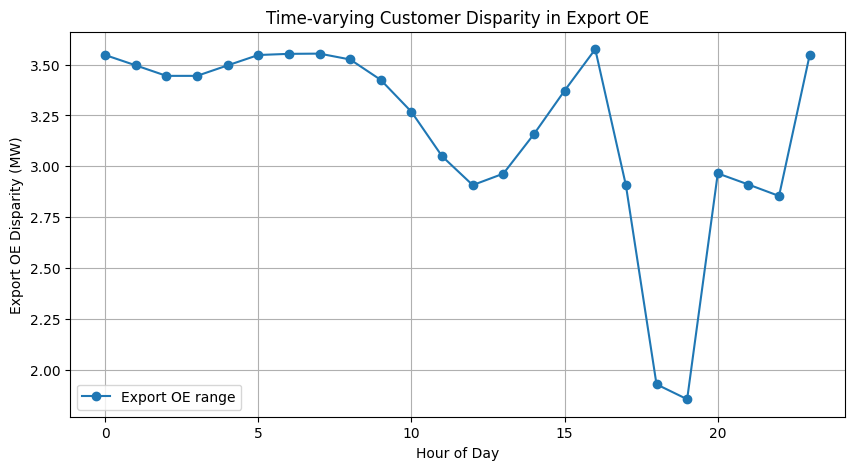

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_disparity.index,
    hourly_disparity["range_OE"],
    marker="o",
    label="Export OE range"
)

plt.xlabel("Hour of Day")
plt.ylabel("Export OE Disparity (MW)")
plt.title("Time-varying Customer Disparity in Export OE")

plt.grid(True)
plt.legend()
plt.show()


The customer disparity is changing over time.
This indicates that both network location and operating conditions influence customer flexibility.

# 9. Dynamic OE vs Fixed Export Limit

The fixed export limit is chosen as the minimum feasible export OE across all feasible node-hour cases.

Both dynamic OE and fixed limit approaches are compared over the same set of feasible node-hour cases.

In [16]:
print("\nFixed Export Limit Comparison")
print("-----------------------------")

df_feasible = df_tv[
    (df_tv["export_OE"].notna()) &
    (df_tv["export_status"] == "optimal")
].copy()

fixed_export_limit = df_feasible["export_OE"].min()

total_export_capacity_oe = df_feasible["export_OE"].sum()

total_export_capacity_fixed = (
    fixed_export_limit
    * len(df_feasible)
)

benefit_MW = (
    total_export_capacity_oe
    - total_export_capacity_fixed
)

benefit_percent = (
    benefit_MW
    / total_export_capacity_fixed
    * 100
    if total_export_capacity_fixed > 0
    else np.nan
)

print(
    f"Fixed export limit                        : "
    f"{fixed_export_limit:.4f} MW"
)

print(
    f"Total export capacity — Dynamic OE        : "
    f"{total_export_capacity_oe:.3f}"
)

print(
    f"Total export capacity — Fixed limit       : "
    f"{total_export_capacity_fixed:.3f}"
)

print(
    f"Additional capacity enabled by dynamic OE : "
    f"{benefit_MW:.3f} ({benefit_percent:.1f}%)"
)


Fixed Export Limit Comparison
-----------------------------
Fixed export limit                        : 1.0366 MW
Total export capacity — Dynamic OE        : 505.730
Total export capacity — Fixed limit       : 211.465
Additional capacity enabled by dynamic OE : 294.265 (139.2%)


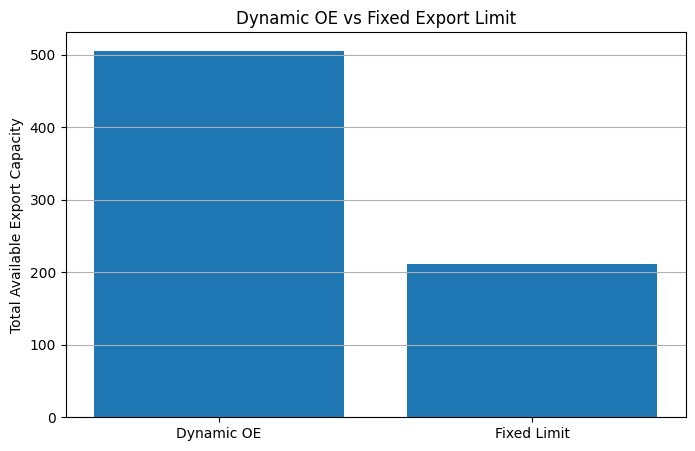

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Dynamic OE", "Fixed Limit"],
    [
        total_export_capacity_oe,
        total_export_capacity_fixed
    ]
)

plt.ylabel("Total Available Export Capacity")
plt.title("Dynamic OE vs Fixed Export Limit")

plt.grid(axis="y")
plt.show()

The dynamic OE approach provides substantially greater available export capacity than a conservative fixed export limit.
This demonstrates the potential benefit of customer-specific and time-varying operating envelopes compared with a single uniform export limit.

# 10. Conclusions and Next Steps
This prototype has established the core OPF-based framework for computing export and import operating envelopes on a radial distribution feeder. The key things I have managed to get working at this stage are the linearised DistFlow model, the per-node time-varying OE calculation, and some initial analysis of which constraints tend to be binding and how much OE varies across customers.


The things I want to look at next are how sensitive the OE results are to DER capacity and location, what happens when multiple customers have DER at the same time, and which constraints are most likely to bind in the real network.. The comparison with fixed export limits is also something I want to develop further, since that directly relates to the main project objective of quantifying the benefit of dynamic OEs.